In [18]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"

import jax
jax.config.update('jax_default_device', 'gpu')
jax.config.update('jax_default_matmul_precision', 'highest')

In [19]:
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.linalg import orthogonal_procrustes

from sppcax.distributions import (
    MultivariateNormalInverseGamma as MVNIG,
    MeanField,
    MultivariateNormal,
)
from sppcax.distributions.gamma import InverseGamma

from sppcax.models import (
    BayesianFactorAnalysis as BFA,
    BayesianDynamicFactorAnalysis as BDFA,
)
from dynamax.linear_gaussian_ssm import parallel_lgssm_smoother

# MeanField(MVN, IG) vs Conjugate MVNIG Emission Prior

This notebook compares two emission prior formulations:

- **MVNIG (conjugate coupled)**: $w_d \mid \sigma^2_d \sim \mathcal{N}(m_d, \sigma^2_d \Lambda_d^{-1})$, $\sigma^2_d \sim \text{IG}(\alpha, \beta)$. The noise scales the weight covariance, enabling conjugate closed-form updates.

- **MeanField(MVN, IG) (factorized)**: $q(W) q(\sigma^2) = \prod_d \mathcal{N}(w_d; m_d, V_d) \cdot \text{IG}(\sigma^2_d; \alpha_d, \beta_d)$. The weight and noise posteriors are independent, updated via coordinate ascent.

Both are tested with ARD, PX rotation, and BMR enabled, using PX-VBEM fitting on FA and DFA models.

In [20]:
def procrustes_similarity(H_est, H_true):
    """Align H_est to H_true via orthogonal Procrustes."""
    D, K_est = H_est.shape
    K_true = H_true.shape[1]
    K_max = max(K_est, K_true)

    A = jnp.pad(H_est, [(0, 0), (0, K_max - K_est)]) if K_est < K_max else H_est
    B = jnp.pad(H_true, [(0, 0), (0, K_max - K_true)]) if K_true < K_max else H_true

    R, _ = orthogonal_procrustes(A, B)
    H_aligned = A @ R
    disparity = jnp.linalg.norm(H_aligned - B, 'fro')
    return H_aligned, float(disparity), R


def make_mf_emission_prior(n_features, dim, isotropic_noise=False):
    """Create a MeanField(MVN, InverseGamma) emission prior."""
    weights = MultivariateNormal(loc=jnp.zeros((n_features, dim)))
    if isotropic_noise:
        noise = InverseGamma(alpha0=2.0, beta0=1.0)
    else:
        noise = InverseGamma(
            alpha0=2.0 * jnp.ones(n_features),
            beta0=1.0 * jnp.ones(n_features),
        )
    return MeanField(weights=weights, noise=noise)

---
## Part 1: Factor Analysis (Static)

### 1.1 Generate Synthetic FA Data

Y shape: (200, 20), H_true shape: (20, 2)
H_true sparsity: 42.5% zeros


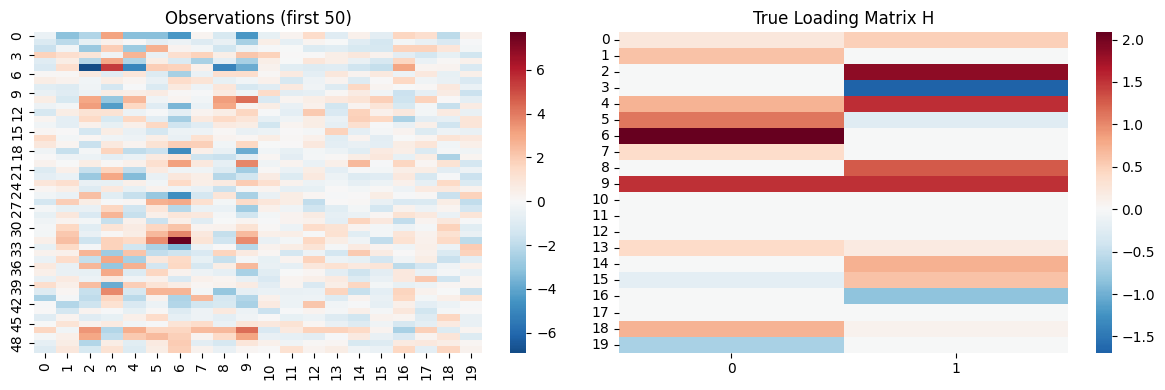

In [21]:
N = 200   # observations
D = 20    # features
K = 2    # latent components

key = jr.PRNGKey(137)

# True sparse loading matrix
key, k1, k2 = jr.split(key, 3)
H_true_fa = jr.normal(k1, (D, K)) * jr.bernoulli(k2, p=0.5, shape=(D, K))

# True diagonal noise covariance
key, k1 = jr.split(key)
R_true_diag_fa = jr.uniform(k1, (D,), minval=0.3, maxval=1.0)

# Generate data: z ~ N(0, I), y = H z + noise
key, k1, k2 = jr.split(key, 3)
Z_true_fa = jr.normal(k1, (N, K))
noise_fa = jr.normal(k2, (N, D)) * jnp.sqrt(R_true_diag_fa)
Y_fa = Z_true_fa @ H_true_fa.T + noise_fa

print(f"Y shape: {Y_fa.shape}, H_true shape: {H_true_fa.shape}")
print(f"H_true sparsity: {jnp.isclose(H_true_fa, 0.).mean():.1%} zeros")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(Y_fa[:50], ax=axes[0], cmap='RdBu_r', center=0)
axes[0].set_title('Observations (first 50)')
sns.heatmap(H_true_fa, ax=axes[1], cmap='RdBu_r', center=0)
axes[1].set_title('True Loading Matrix H')
plt.tight_layout()

### 1.2 Fit PX-VBEM with MVNIG vs MeanField Emission Prior

In [22]:
NUM_ITERS = 20
comp_dim = 2 * K  # overspecify to test ARD/BMR pruning
has_bias = True
param_dim = comp_dim + has_bias  # columns in emission matrix

# --- MVNIG prior (conjugate) ---
model_mvnig = BFA(comp_dim, D, has_ard=True, use_bmr=True, use_px=True)
key, k1, k2 = jr.split(key, 3)
params_init_mvnig, props_mvnig = model_mvnig.initialize(k1, variational_bayes=True)
params_mvnig, elbos_mvnig = model_mvnig.fit_vbem(
    params_init_mvnig, props_mvnig, Y_fa, k2,
    num_iters=NUM_ITERS, bmr_start_iter=8)
print(f"MVNIG PX-VBEM+BMR final ELBO: {elbos_mvnig[-1]:.1f}")

# --- MeanField(MVN, IG) prior (factorized) ---
mf_prior = make_mf_emission_prior(D, param_dim)
model_mf = BFA(comp_dim, D, has_ard=True, use_bmr=True, use_px=True,
               emission_prior=mf_prior)
key, k1, k2 = jr.split(key, 3)
params_init_mf, props_mf = model_mf.initialize(k1, variational_bayes=True)
params_mf, elbos_mf = model_mf.fit_vbem(
    params_init_mf, props_mf, Y_fa, k2,
    num_iters=NUM_ITERS, bmr_start_iter=8)
print(f"MeanField PX-VBEM+BMR final ELBO: {elbos_mf[-1]:.1f}")

MVNIG PX-VBEM+BMR final ELBO: -5222.3
MeanField PX-VBEM+BMR final ELBO: -5197.7


### 1.3 ELBO Convergence Comparison (FA)

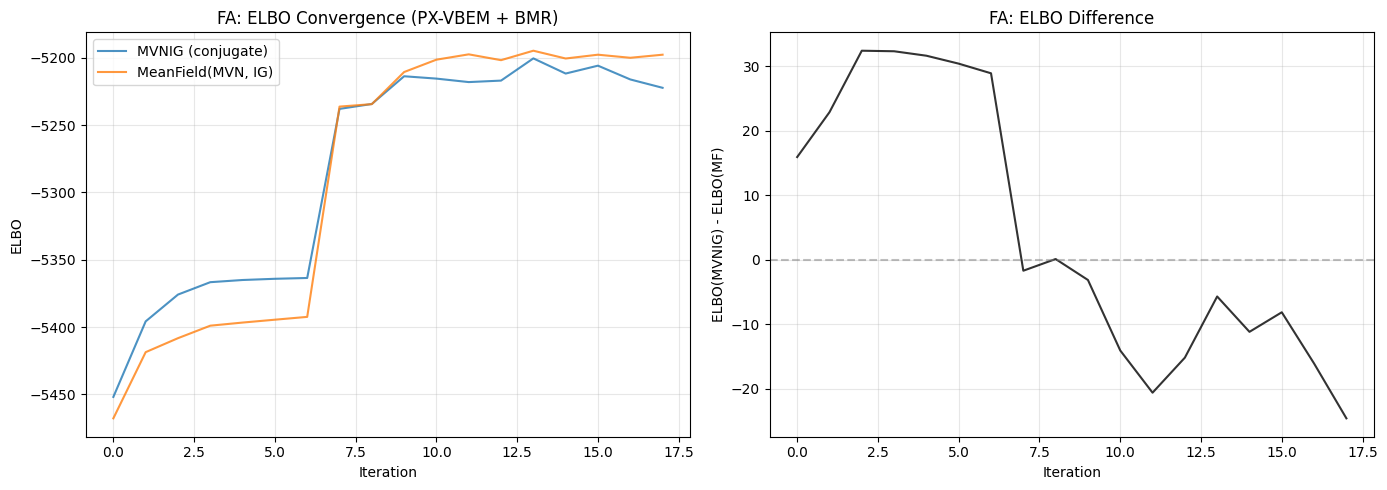

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(elbos_mvnig[1:], label='MVNIG (conjugate)', alpha=0.8)
ax.plot(elbos_mf[1:], label='MeanField(MVN, IG)', alpha=0.8)
ax.set_xlabel('Iteration')
ax.set_ylabel('ELBO')
ax.set_title('FA: ELBO Convergence (PX-VBEM + BMR)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(elbos_mvnig[1:] - elbos_mf[1:], 'k-', alpha=0.8)
ax.axhline(0, ls='--', color='gray', alpha=0.5)
ax.set_xlabel('Iteration')
ax.set_ylabel('ELBO(MVNIG) - ELBO(MF)')
ax.set_title('FA: ELBO Difference')
ax.grid(True, alpha=0.3)

plt.tight_layout()

### 1.4 Loading Matrix Recovery (FA)

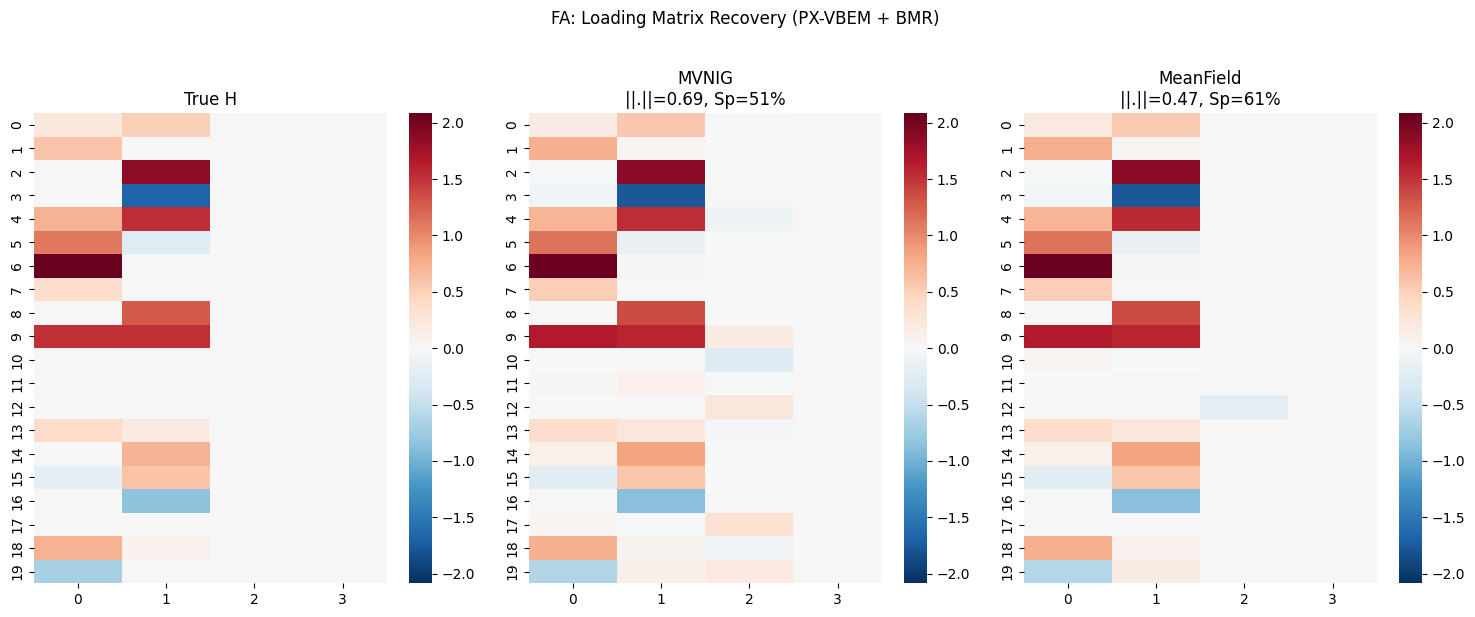

In [24]:
results_fa = {
    'MVNIG': params_mvnig.emissions.weights,
    'MeanField': params_mf.emissions.weights,
}

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
vmax = jnp.abs(H_true_fa).max()

sns.heatmap(jnp.pad(H_true_fa, [(0, 0), (0, K)]),
            ax=axes[0], cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax)
axes[0].set_title('True H')

for idx, (name, H_est) in enumerate(results_fa.items()):
    H_aligned, disparity, _ = procrustes_similarity(H_est, H_true_fa)
    sparsity = jnp.mean(jnp.abs(H_est) < 0.05)
    sns.heatmap(H_aligned, ax=axes[idx + 1], cmap='RdBu_r', center=0,
                vmin=-vmax, vmax=vmax)
    axes[idx + 1].set_title(f'{name}\n||.||={disparity:.2f}, Sp={sparsity:.0%}')

plt.suptitle('FA: Loading Matrix Recovery (PX-VBEM + BMR)', y=1.02)
plt.tight_layout()

### 1.5 Noise Variance Recovery (FA)

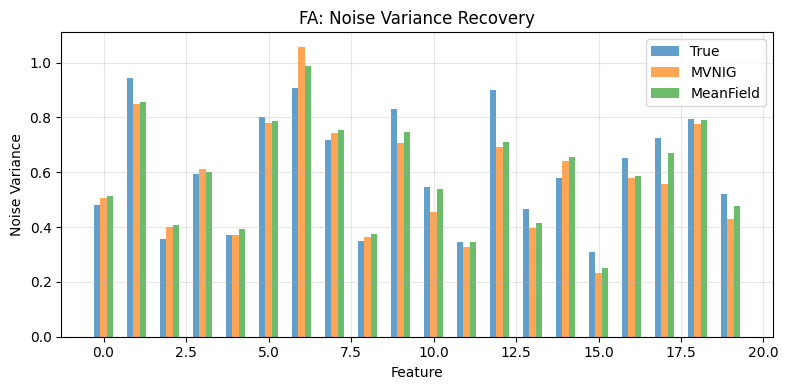

In [25]:
R_est_mvnig = params_mvnig.emissions.cov
R_est_mf = params_mf.emissions.cov

# Handle 1D vs 2D noise representation
R_mvnig_diag = R_est_mvnig if R_est_mvnig.ndim == 1 else jnp.diag(R_est_mvnig)
R_mf_diag = R_est_mf if R_est_mf.ndim == 1 else jnp.diag(R_est_mf)

fig, ax = plt.subplots(figsize=(8, 4))
x = jnp.arange(D)
ax.bar(x - 0.2, R_true_diag_fa, width=0.2, label='True', alpha=0.7)
ax.bar(x, R_mvnig_diag, width=0.2, label='MVNIG', alpha=0.7)
ax.bar(x + 0.2, R_mf_diag, width=0.2, label='MeanField', alpha=0.7)
ax.set_xlabel('Feature')
ax.set_ylabel('Noise Variance')
ax.set_title('FA: Noise Variance Recovery')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

---
## Part 2: Dynamic Factor Analysis

### 2.1 Generate Synthetic DFA Data

The latent state is 4-dimensional with **fully coupled** dynamics: F is a damped
4D rotation (product of Givens rotations in overlapping planes). Only the first 2
components drive observations ($\mathbf{H}$ columns 3-4 are zero), but because F
couples all dimensions, the unobserved components influence future observed components.
This tests whether the model can discover the full latent structure through temporal dynamics.

F_true eigenvalues: [0.5992248 +0.73717695j 0.5992248 -0.73717695j 0.91912365+0.24023227j
 0.91912365-0.24023227j]
F_true is fully coupled (no block-diagonal structure):
[[ 0.823      -0.384       0.252      -0.12100001]
 [ 0.47500002  0.666      -0.43600002  0.21000001]
 [ 0.          0.558       0.69200003 -0.333     ]
 [ 0.          0.          0.41200003  0.85600007]]

y_obs shape: (200, 20), H_true shape: (20, 4)
H_true: 2 active columns, 2 zero columns
H_true sparsity: 71.3% zeros


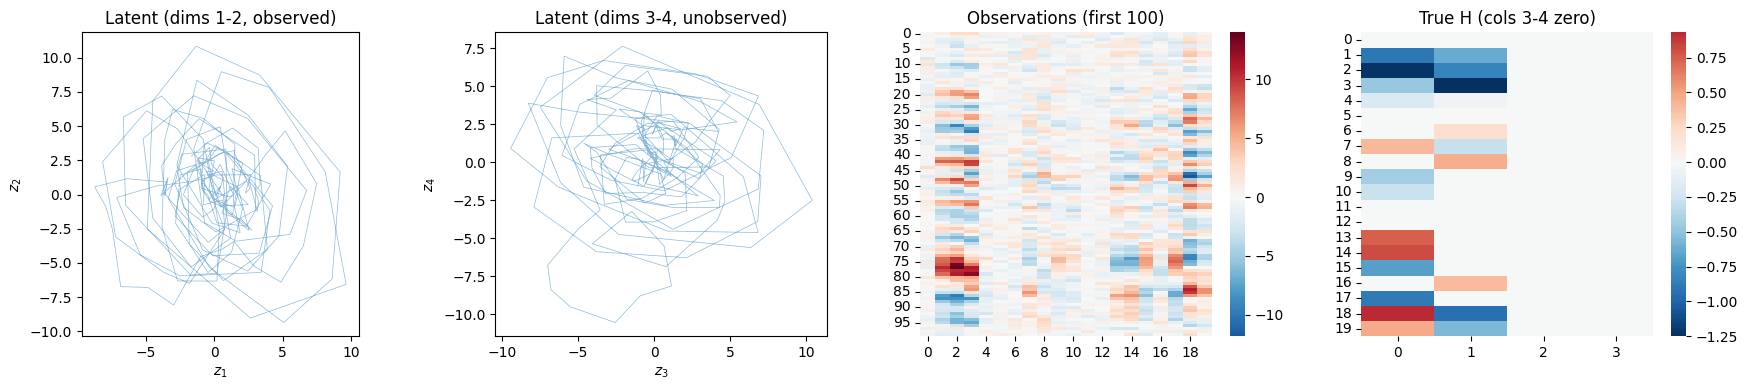

In [26]:
T = 200   # time steps
D = 20    # features
K = 4     # latent state dimension
K_obs = 2 # only first 2 components drive observations

key = jr.PRNGKey(42)

# True dynamics: damped rotation in 4D (all dimensions coupled)
# Build F as product of rotations in the (1,2), (1,3), and (2,4) planes
# so all 4 dimensions are mixed — dynamics in the unobserved plane
# propagate into the observed plane through F.
rho = 0.95

def rotation_4d(plane, angle):
    """4D rotation matrix in the given plane (i,j)."""
    R = jnp.eye(4)
    i, j = plane
    R = R.at[i, i].set(jnp.cos(angle))
    R = R.at[i, j].set(-jnp.sin(angle))
    R = R.at[j, i].set(jnp.sin(angle))
    R = R.at[j, j].set(jnp.cos(angle))
    return R

# Compose rotations in two non-orthogonal planes to couple all dims
F_true = rho * (rotation_4d((0, 1), jnp.pi / 6) @
                rotation_4d((1, 2), jnp.pi / 5) @
                rotation_4d((2, 3), jnp.pi / 7))
Q_true = jnp.eye(K)

print(f"F_true eigenvalues: {jnp.linalg.eigvals(F_true)}")
print(f"F_true is fully coupled (no block-diagonal structure):")
print(jnp.round(F_true, 3))

# True loading matrix: only first K_obs columns are non-zero
key, k1, k2 = jr.split(key, 3)
H_active = jr.normal(k1, (D, K_obs)) * jr.bernoulli(k2, p=0.5, shape=(D, K_obs))
H_true_dfa = jnp.concatenate([H_active, jnp.zeros((D, K - K_obs))], axis=1)

# True diagonal noise covariance
key, k1 = jr.split(key)
R_true_diag_dfa = jr.uniform(k1, (D,), minval=0.25, maxval=1.0)
R_true = jnp.diag(R_true_diag_dfa)

# Generate latent states and observations
mu0_true = jnp.zeros(K)
Sigma0_true = jnp.eye(K)

z_true = jnp.zeros((T, K))
y_obs = jnp.zeros((T, D))

key, k1, k2 = jr.split(key, 3)
z_curr = jr.multivariate_normal(k1, mu0_true, Sigma0_true)
z_true = z_true.at[0].set(z_curr)
y_obs = y_obs.at[0].set(jr.multivariate_normal(k2, H_true_dfa @ z_curr, R_true))

for t in range(1, T):
    key, k1, k2 = jr.split(key, 3)
    z_curr = jr.multivariate_normal(k1, F_true @ z_curr, Q_true)
    z_true = z_true.at[t].set(z_curr)
    y_obs = y_obs.at[t].set(jr.multivariate_normal(k2, H_true_dfa @ z_curr, R_true))

print(f"\ny_obs shape: {y_obs.shape}, H_true shape: {H_true_dfa.shape}")
print(f"H_true: {K_obs} active columns, {K - K_obs} zero columns")
print(f"H_true sparsity: {jnp.isclose(H_true_dfa, 0.).mean():.1%} zeros")

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].plot(z_true[:, 0], z_true[:, 1], alpha=0.5, lw=0.5)
axes[0].set_xlabel('$z_1$'); axes[0].set_ylabel('$z_2$')
axes[0].set_title('Latent (dims 1-2, observed)')
axes[0].set_aspect('equal')
axes[1].plot(z_true[:, 2], z_true[:, 3], alpha=0.5, lw=0.5)
axes[1].set_xlabel('$z_3$'); axes[1].set_ylabel('$z_4$')
axes[1].set_title('Latent (dims 3-4, unobserved)')
axes[1].set_aspect('equal')
sns.heatmap(y_obs[:100], ax=axes[2], cmap='RdBu_r', center=0)
axes[2].set_title('Observations (first 100)')
sns.heatmap(H_true_dfa, ax=axes[3], cmap='RdBu_r', center=0)
axes[3].set_title('True H (cols 3-4 zero)')
plt.tight_layout()

### 2.2 Fit PX-VBEM with MVNIG vs MeanField Emission Prior

In [27]:
NUM_ITERS = 20
comp_dim_dfa = K  # use true state dim; ARD/BMR should prune unobserved columns
has_bias_dfa = True
param_dim_dfa = comp_dim_dfa + has_bias_dfa

# --- MVNIG prior (conjugate) ---
model_mvnig_dfa = BDFA(comp_dim_dfa, D, has_ard=True, use_bmr=True, use_px=True)
key, k1, k2 = jr.split(key, 3)
params_init_mvnig_dfa, props_mvnig_dfa = model_mvnig_dfa.initialize(
    k1, variational_bayes=True)
params_mvnig_dfa, elbos_mvnig_dfa = model_mvnig_dfa.fit_vbem(
    params_init_mvnig_dfa, props_mvnig_dfa, y_obs, k2,
    num_iters=NUM_ITERS, bmr_start_iter=8)
print(f"MVNIG PX-VBEM+BMR final ELBO: {elbos_mvnig_dfa[-1]:.1f}")

# --- MeanField(MVN, IG) prior (factorized) ---
mf_prior_dfa = make_mf_emission_prior(D, param_dim_dfa)
model_mf_dfa = BDFA(comp_dim_dfa, D, has_ard=True, use_bmr=True, use_px=True,
                     emission_prior=mf_prior_dfa)
key, k1, k2 = jr.split(key, 3)
params_init_mf_dfa, props_mf_dfa = model_mf_dfa.initialize(
    k1, variational_bayes=True)
params_mf_dfa, elbos_mf_dfa = model_mf_dfa.fit_vbem(
    params_init_mf_dfa, props_mf_dfa, y_obs, k2,
    num_iters=NUM_ITERS, bmr_start_iter=8)
print(f"MeanField PX-VBEM+BMR final ELBO: {elbos_mf_dfa[-1]:.1f}")

MVNIG PX-VBEM+BMR final ELBO: -5329.3
MeanField PX-VBEM+BMR final ELBO: -5304.5


### 2.3 ELBO Convergence Comparison (DFA)

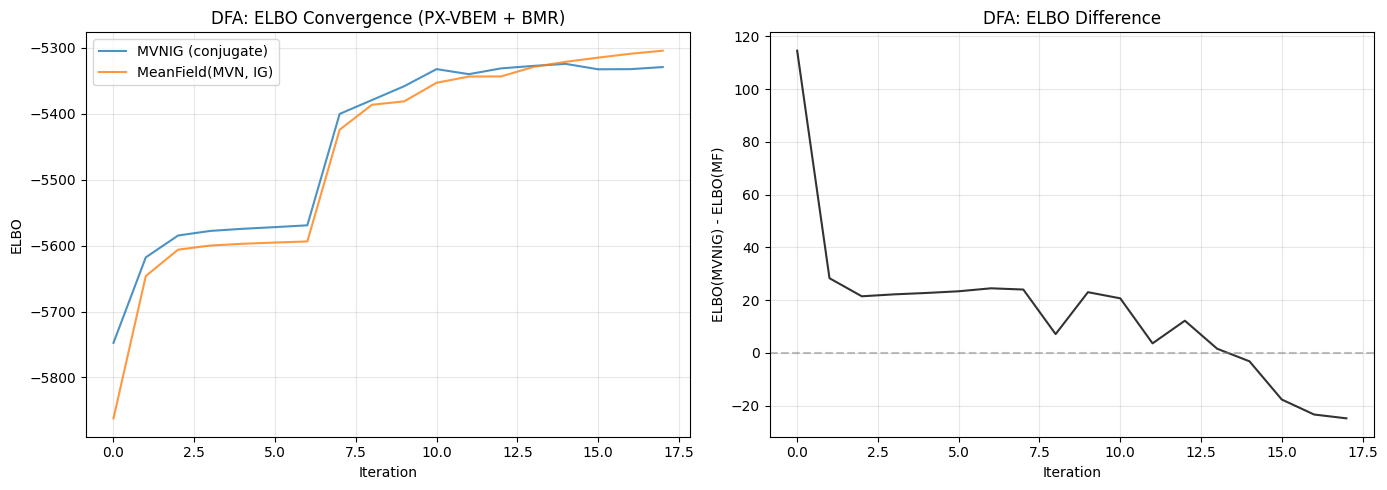

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(elbos_mvnig_dfa[1:], label='MVNIG (conjugate)', alpha=0.8)
ax.plot(elbos_mf_dfa[1:], label='MeanField(MVN, IG)', alpha=0.8)
ax.set_xlabel('Iteration')
ax.set_ylabel('ELBO')
ax.set_title('DFA: ELBO Convergence (PX-VBEM + BMR)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(elbos_mvnig_dfa[1:] - elbos_mf_dfa[1:], 'k-', alpha=0.8)
ax.axhline(0, ls='--', color='gray', alpha=0.5)
ax.set_xlabel('Iteration')
ax.set_ylabel('ELBO(MVNIG) - ELBO(MF)')
ax.set_title('DFA: ELBO Difference')
ax.grid(True, alpha=0.3)

plt.tight_layout()

### 2.4 Loading Matrix Recovery (DFA)

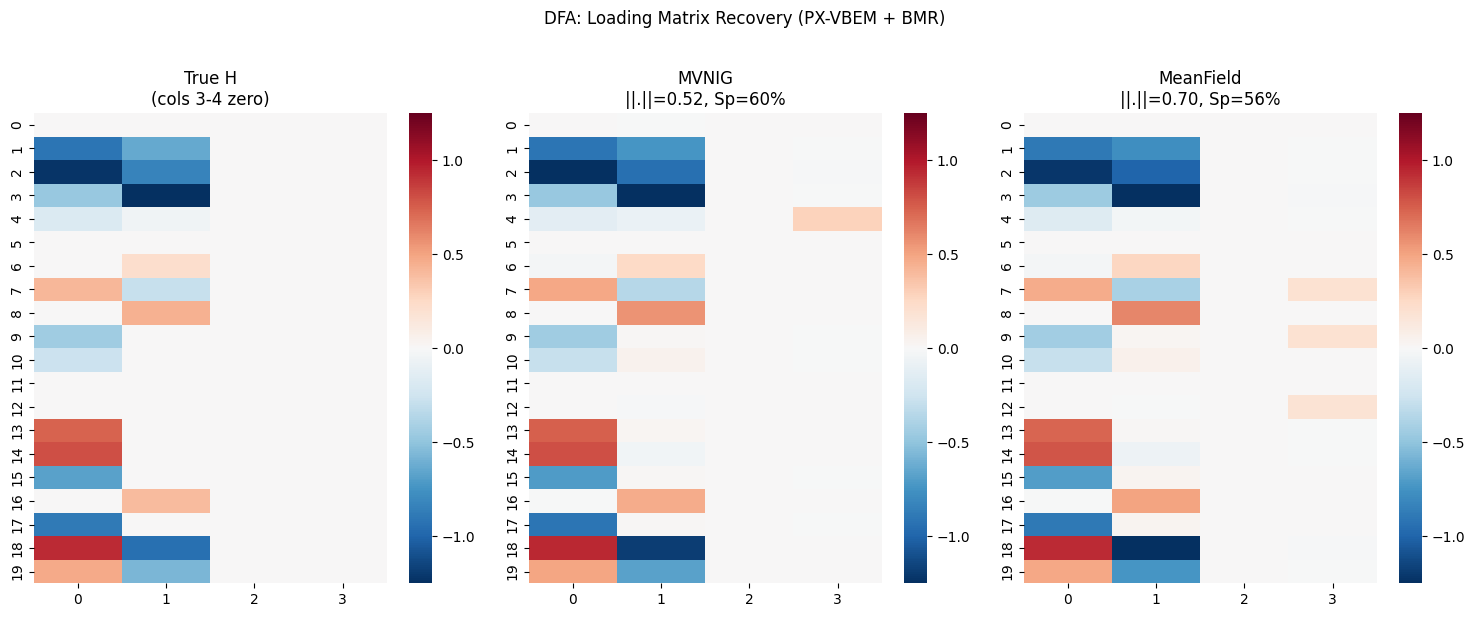

In [29]:
results_dfa = {
    'MVNIG': params_mvnig_dfa,
    'MeanField': params_mf_dfa,
}

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
vmax = jnp.abs(H_true_dfa).max()

sns.heatmap(H_true_dfa, ax=axes[0], cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax)
axes[0].set_title('True H\n(cols 3-4 zero)')

procrustes_Rs = {}
for idx, (name, p) in enumerate(results_dfa.items()):
    H_aligned, disparity, R = procrustes_similarity(p.emissions.weights, H_true_dfa)
    procrustes_Rs[name] = R
    sparsity = jnp.mean(jnp.abs(p.emissions.weights) < 0.05)
    sns.heatmap(H_aligned, ax=axes[idx + 1], cmap='RdBu_r', center=0,
                vmin=-vmax, vmax=vmax)
    axes[idx + 1].set_title(f'{name}\n||.||={disparity:.2f}, Sp={sparsity:.0%}')

plt.suptitle('DFA: Loading Matrix Recovery (PX-VBEM + BMR)', y=1.02)
plt.tight_layout()

### 2.5 Transition Matrix Recovery (DFA)

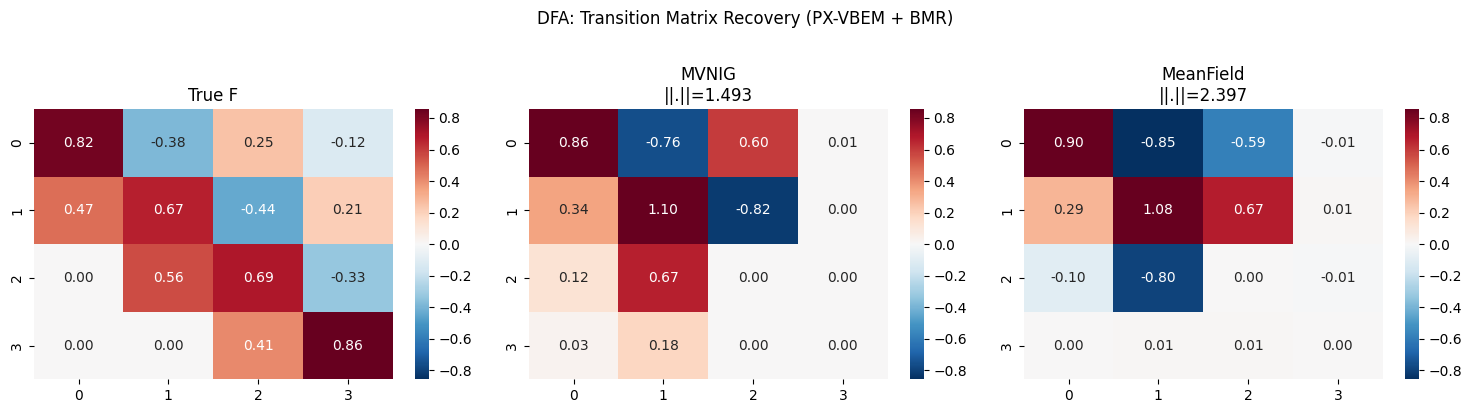

In [30]:
K_est = params_mvnig_dfa.dynamics.weights.shape[0]
K_max = max(K_est, K)
F_true_pad = jnp.pad(F_true, [(0, K_max - K), (0, K_max - K)])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
vmax_f = max(float(jnp.abs(F_true).max()), 0.5)

sns.heatmap(F_true_pad, ax=axes[0], cmap='RdBu_r', center=0,
            vmin=-vmax_f, vmax=vmax_f, annot=True, fmt='.2f')
axes[0].set_title('True F')

for idx, (name, p) in enumerate(results_dfa.items()):
    R = procrustes_Rs[name]
    F_aligned = R.T @ p.dynamics.weights @ R
    err = jnp.linalg.norm(F_aligned - F_true_pad, 'fro')
    sns.heatmap(F_aligned, ax=axes[idx + 1], cmap='RdBu_r', center=0,
                vmin=-vmax_f, vmax=vmax_f, annot=True, fmt='.2f')
    axes[idx + 1].set_title(f'{name}\n||.||={err:.3f}')

plt.suptitle('DFA: Transition Matrix Recovery (PX-VBEM + BMR)', y=1.02)
plt.tight_layout()

### 2.6 Latent State Recovery (DFA)

The first 2 latent components (observed plane) should be well-recovered.
The last 2 (unobserved plane) have no data constraint and will not match the true trajectory.

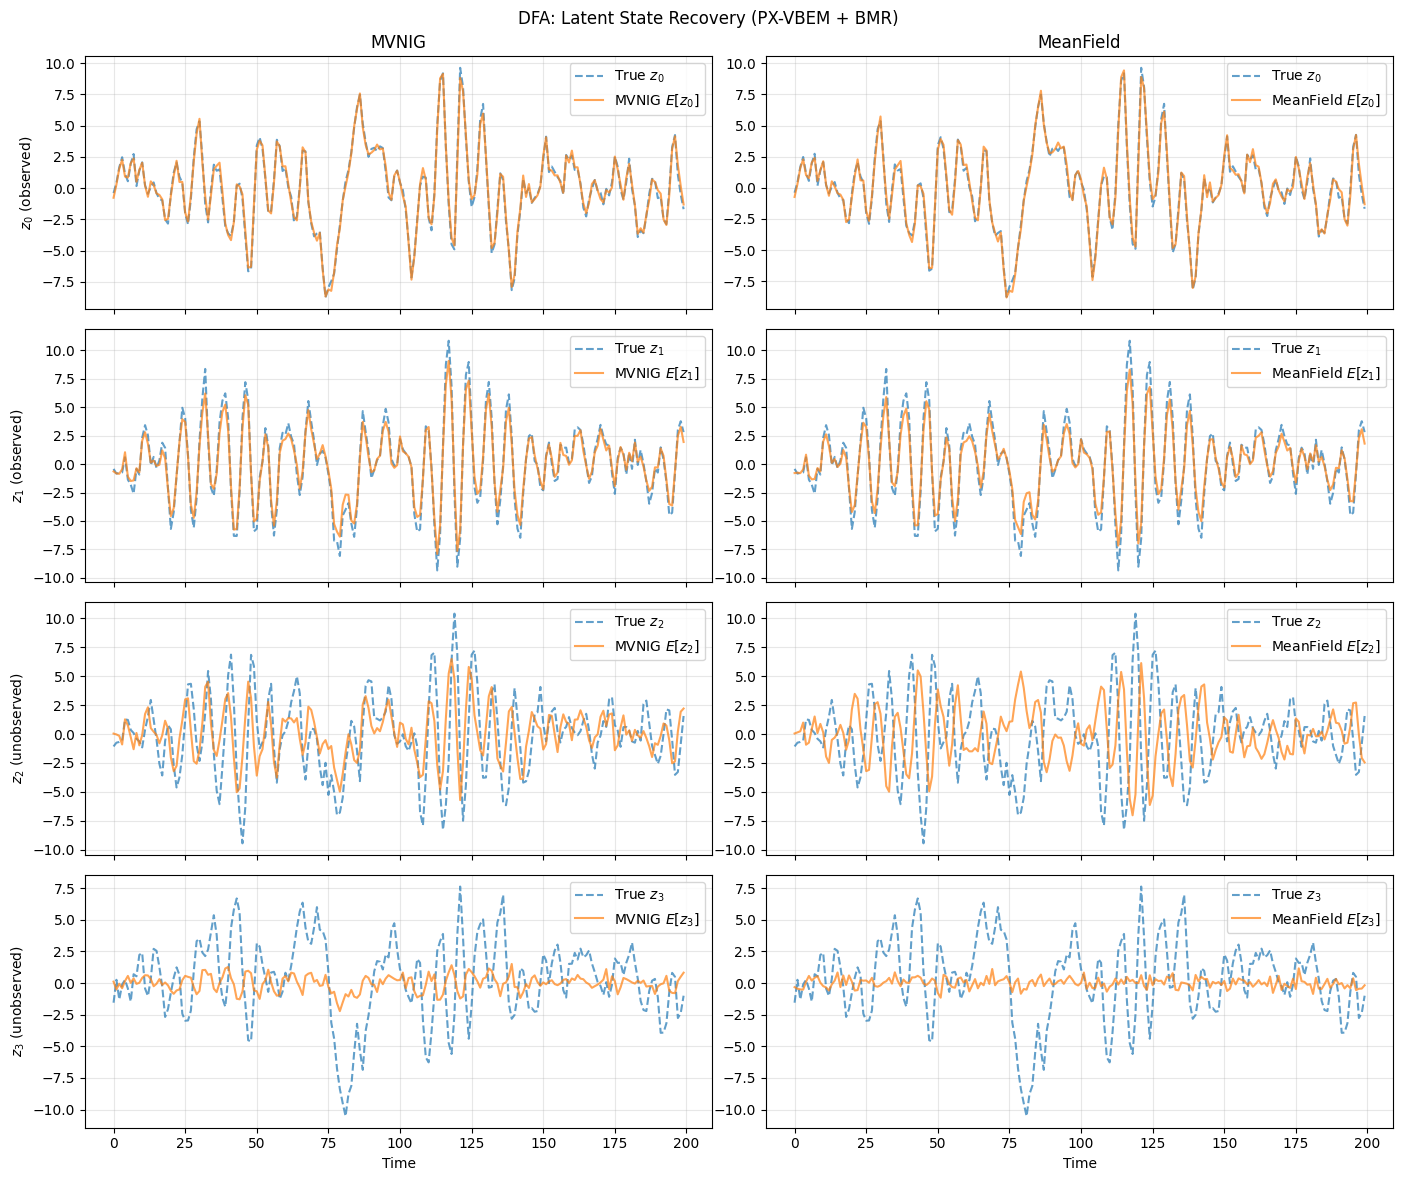

In [31]:
fig, axes = plt.subplots(K, 2, figsize=(14, 3 * K), sharex=True)

for col, (name, p) in enumerate(results_dfa.items()):
    R = procrustes_Rs[name]
    post = parallel_lgssm_smoother(p, y_obs)
    Ez = jax.scipy.linalg.solve(R, post.smoothed_means[..., None])[..., 0]

    for i in range(K):
        label_suffix = ' (observed)' if i < K_obs else ' (unobserved)'
        axes[i, col].plot(z_true[:, i], label=f'True $z_{i}$', ls='--', alpha=0.7)
        axes[i, col].plot(Ez[:, i], label=f'{name} $E[z_{i}]$', alpha=0.7)
        axes[i, col].legend(loc='upper right')
        axes[i, col].grid(True, alpha=0.3)
        if i == 0:
            axes[i, col].set_title(name)
        axes[i, 0].set_ylabel(f'$z_{i}${label_suffix}')

axes[-1, 0].set_xlabel('Time')
axes[-1, 1].set_xlabel('Time')
plt.suptitle('DFA: Latent State Recovery (PX-VBEM + BMR)')
plt.tight_layout()

### 2.7 Noise Variance Recovery (DFA)

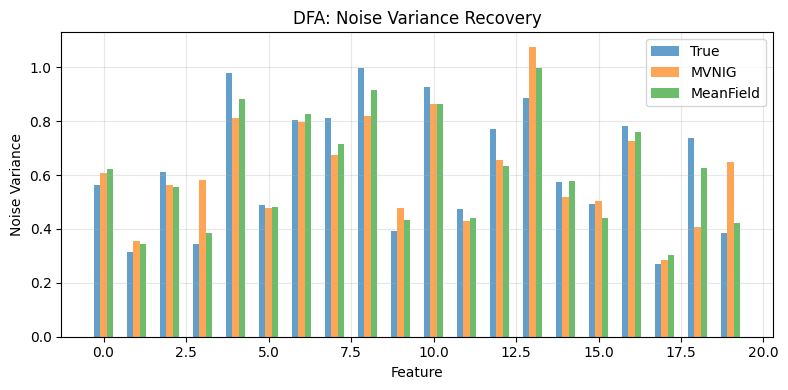

In [32]:
R_est_mvnig_dfa = params_mvnig_dfa.emissions.cov
R_est_mf_dfa = params_mf_dfa.emissions.cov

R_mvnig_diag_dfa = R_est_mvnig_dfa if R_est_mvnig_dfa.ndim == 1 else jnp.diag(R_est_mvnig_dfa)
R_mf_diag_dfa = R_est_mf_dfa if R_est_mf_dfa.ndim == 1 else jnp.diag(R_est_mf_dfa)

fig, ax = plt.subplots(figsize=(8, 4))
x = jnp.arange(D)
ax.bar(x - 0.2, R_true_diag_dfa, width=0.2, label='True', alpha=0.7)
ax.bar(x, R_mvnig_diag_dfa, width=0.2, label='MVNIG', alpha=0.7)
ax.bar(x + 0.2, R_mf_diag_dfa, width=0.2, label='MeanField', alpha=0.7)
ax.set_xlabel('Feature')
ax.set_ylabel('Noise Variance')
ax.set_title('DFA: Noise Variance Recovery')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()